**Goal:** turn a set of relationships into a **graph** you can measure. You will build and inspect a
network in NetworkX, write it as an **adjacency matrix** and run the L18 matrix operations on it (row
sums give degree, `A @ A` counts shared friends), find the important nodes with three kinds of
**centrality**, and zoom into a node's **ego network**. The running graph is Zachary's Karate Club --
34 members, 78 friendships -- which ships inside NetworkX. Pairs with the concept note
[Social Networks as Graphs](l25_concept_social_networks_graphs.qmd).

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devomh/cdat4001-2026/blob/main/u07_social_networks/l25_lab_social_networks_graphs.ipynb)

> This page is the read-only view. To run the lab, open the notebook
> (`l25_lab_social_networks_graphs.ipynb`) -- in Colab via the badge above, or
> locally. No data download is needed: the graph is built into NetworkX. Every
> text output below comes from actually running the cells.

## Prerequisites & Setup

We use **Zachary's Karate Club** (Zachary, 1977): the friendships among 34 members of a university
karate club that later split into two factions. It is the "hello world" of network science and is
bundled with **NetworkX**, so there is nothing to download.

In [1]:
# Setup cell 1 of 2: install only (Colab resets on open; run this first)
%pip install -q networkx pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup cell 2 of 2: imports + load the built-in graph. Safe to re-run.
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)

G = nx.karate_club_graph()
print("Loaded Zachary's Karate Club:",
      G.number_of_nodes(), "nodes,", G.number_of_edges(), "edges.")

Loaded Zachary's Karate Club: 34 nodes, 78 edges.


<details><summary>Expected Output</summary>

~~~text
Loaded Zachary's Karate Club: 34 nodes, 78 edges.
~~~
</details>

## Step 1 -- Build and inspect a graph

A graph is nodes plus edges. NetworkX lets you ask it anything: is it directed? how dense? who are a
node's neighbours? Node `0` is the instructor ("Mr. Hi") and node `33` is the club president ("the
Officer") -- the two who later split the club. The `club` attribute records which faction each member
ended up in; we only *name* it here (community detection is L26).

In [3]:
print("Directed?", G.is_directed())
print("Nodes:", G.number_of_nodes(), "| Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 4))
print("Neighbours of node 0:", sorted(G.neighbors(0)))
print("Friends with node 1?", G.has_edge(0, 1), "| with node 9?", G.has_edge(0, 9))
print("Node 0 club:", G.nodes[0]["club"], "| node 33 club:", G.nodes[33]["club"])

Directed? False
Nodes: 34 | Edges: 78
Density: 0.139
Neighbours of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Friends with node 1? True | with node 9? False
Node 0 club: Mr. Hi | node 33 club: Officer


<details><summary>Expected Output</summary>

~~~text
Directed? False
Nodes: 34 | Edges: 78
Density: 0.139
Neighbours of node 0: [1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 17, 19, 21, 31]
Friends with node 1? True | with node 9? False
Node 0 club: Mr. Hi | node 33 club: Officer
~~~
</details>

The graph is **undirected** (friendship is mutual) and **sparse** (density 0.139 -- only ~14% of all
possible friendships exist). One subtlety: the built-in edges carry an interaction-count **weight**, so
this is technically a weighted graph. We will take the **binary** view (tie present or not) in Step 2.

In [4]:
print("Edge (0, 1) stored data:", G.get_edge_data(0, 1))

Edge (0, 1) stored data: {'weight': 4}


<details><summary>Expected Output</summary>

~~~text
Edge (0, 1) stored data: {'weight': 4}
~~~
</details>

A picture builds intuition. We lay the graph out with a force-directed (`spring`) layout, size each node
by its degree, and mark the two leaders.

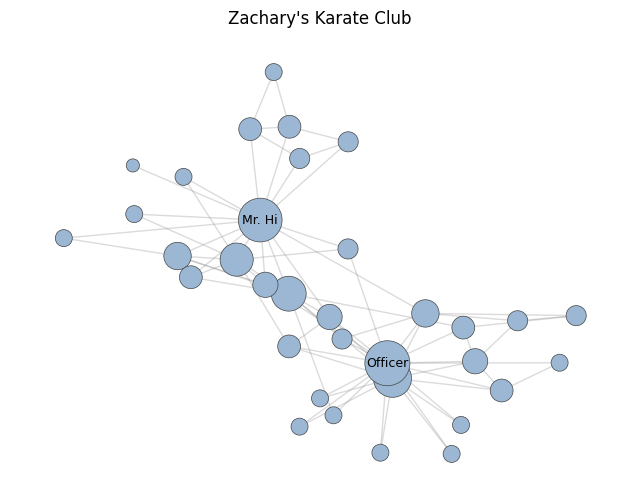

In [5]:
deg = dict(G.degree())
pos = nx.spring_layout(G, seed=42)   # fixed seed -> reproducible layout

plt.figure(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="#888888")
nx.draw_networkx_nodes(G, pos,
                       node_size=[30 + 60 * deg[n] for n in G.nodes()],
                       node_color="#9bb7d4", edgecolors="#444444", linewidths=0.5)
nx.draw_networkx_labels(G, pos, labels={0: "Mr. Hi", 33: "Officer"}, font_size=9)
plt.title("Zachary's Karate Club")
plt.axis("off")
plt.show()

You can build a graph from scratch too -- just hand NetworkX an edge list. Here is a tiny 4-node graph.

In [6]:
H = nx.Graph()
H.add_edges_from([("A", "B"), ("A", "C"), ("B", "C"), ("C", "D")])
print("H:", H.number_of_nodes(), "nodes,", H.number_of_edges(), "edges")
print("H degrees:", dict(H.degree()))

H: 4 nodes, 4 edges
H degrees: {'A': 2, 'B': 2, 'C': 3, 'D': 1}


<details><summary>Expected Output</summary>

~~~text
H: 4 nodes, 4 edges
H degrees: {'A': 2, 'B': 2, 'C': 3, 'D': 1}
~~~
</details>

Node `C` has degree 3 (tied to A, B, and D); `D` has degree 1 (only tied to C). Reading degree off a
graph is just counting edges.

**Try it (completion).** Predict the effect, then run it: attach a new node to `H` and re-read the degrees.

In [7]:
# Completion: attach a new node "E" to "D" only, then reprint H's degrees.
# D's degree should rise by 1 and E's should be 1. Uncomment and complete:
# H.add_edge("D", "___")
# print("H degrees:", dict(H.degree()))

## Step 2 -- The adjacency matrix (the L18 bridge)

Number the nodes `0..33` and build the `34 x 34` table `A` with `A[i, j] = 1` when `i` and `j` are
friends. We pass `weight=None` to get the **binary** adjacency (ignore the interaction weights). Because
the graph is undirected, `A` is **symmetric**.

In [8]:
A = nx.to_numpy_array(G, nodelist=sorted(G.nodes()), dtype=int, weight=None)
print("A shape:", A.shape)
print("Symmetric (A == A.T)?", np.array_equal(A, A.T))
print("A[0, 1] =", A[0, 1], "| A[0, 9] =", A[0, 9], "| A[0, 0] =", A[0, 0])
print("Total 1s in A:", int(A.sum()), "= 2 x edges =", 2 * G.number_of_edges())

A shape: (34, 34)
Symmetric (A == A.T)? True
A[0, 1] = 1 | A[0, 9] = 0 | A[0, 0] = 0
Total 1s in A: 156 = 2 x edges = 156


<details><summary>Expected Output</summary>

~~~text
A shape: (34, 34)
Symmetric (A == A.T)? True
A[0, 1] = 1 | A[0, 9] = 0 | A[0, 0] = 0
Total 1s in A: 156 = 2 x edges = 156
~~~
</details>

Now the **L18 payoff**. Adding up a row of `A` counts that node's friendships -- so the **row sum is the
degree**. Summing every row at once is `A @ ones`: the matrix-times-vector product from L18.

In [9]:
deg_from_matrix = A.sum(axis=1)               # row sums
deg_from_nx = np.array([d for _, d in sorted(G.degree())])
print("Row sums == NetworkX degrees?", np.array_equal(deg_from_matrix, deg_from_nx))
print("Degree of node 0 (row sum):", int(deg_from_matrix[0]))
print("Degree of node 33 (row sum):", int(deg_from_matrix[33]))

Row sums == NetworkX degrees? True
Degree of node 0 (row sum): 16
Degree of node 33 (row sum): 17


<details><summary>Expected Output</summary>

~~~text
Row sums == NetworkX degrees? True
Degree of node 0 (row sum): 16
Degree of node 33 (row sum): 17
~~~
</details>

And the matrix-times-matrix product `A @ A` counts **common neighbours**: entry `(i, j)` is how many
friends `i` and `j` share, and the diagonal `(i, i)` is node `i`'s degree again.

In [10]:
A2 = A @ A
print("(A @ A)[0, 0] =", int(A2[0, 0]), "(= degree of node 0)")
print("(A @ A)[0, 33] =", int(A2[0, 33]), "(shared friends of the two leaders)")
print("Check with NetworkX:", len(list(nx.common_neighbors(G, 0, 33))))

(A @ A)[0, 0] = 16 (= degree of node 0)
(A @ A)[0, 33] = 4 (shared friends of the two leaders)
Check with NetworkX: 4


<details><summary>Expected Output</summary>

~~~text
(A @ A)[0, 0] = 16 (= degree of node 0)
(A @ A)[0, 33] = 4 (shared friends of the two leaders)
Check with NetworkX: 4
~~~
</details>

**Try it (completion).** Confirm the row-sum = degree claim on a node of your choice.

In [11]:
# Completion: pick any node id and check its adjacency row sum equals its degree.
# node = 5
# print("row sum:", int(A[node].sum()), "| G.degree:", G.degree(node))

A picture of `A` makes the structure pop: two denser blocks around the two leaders, with a thin bridge
between them -- the split is already visible in the matrix.

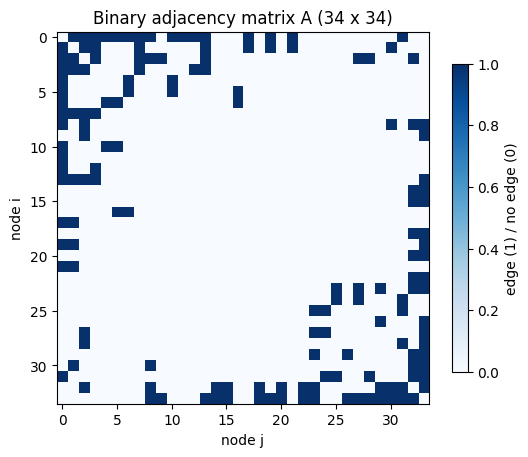

In [12]:
plt.figure(figsize=(6, 5))
plt.imshow(A, cmap="Blues", interpolation="nearest")
plt.title("Binary adjacency matrix A (34 x 34)")
plt.xlabel("node j"); plt.ylabel("node i")
plt.colorbar(label="edge (1) / no edge (0)", shrink=0.8)
plt.show()

## Step 3 -- Degree and the degree distribution

Degree is the simplest measure of a node's importance: how many friends it has. Let us rank the members.

In [13]:
degree_series = pd.Series(dict(G.degree())).sort_values(ascending=False)
print("Top 5 nodes by degree:")
print(degree_series.head(5).to_string())
print("\nMean degree:", round(degree_series.mean(), 3),
      "| min:", degree_series.min(), "| max:", degree_series.max())

Top 5 nodes by degree:
33    17
0     16
32    12
2     10
1      9

Mean degree: 4.588 | min: 1 | max: 17


<details><summary>Expected Output</summary>

~~~text
Top 5 nodes by degree:
33    17
0     16
32    12
2     10
1      9

Mean degree: 4.588 | min: 1 | max: 17
~~~
</details>

The two leaders (33 and 0) are far and away the **hubs**. Most members have only a couple of friends.
That shape -- a few high-degree hubs, a long tail of low-degree nodes -- is the **heavy-tailed degree
distribution** typical of social networks.

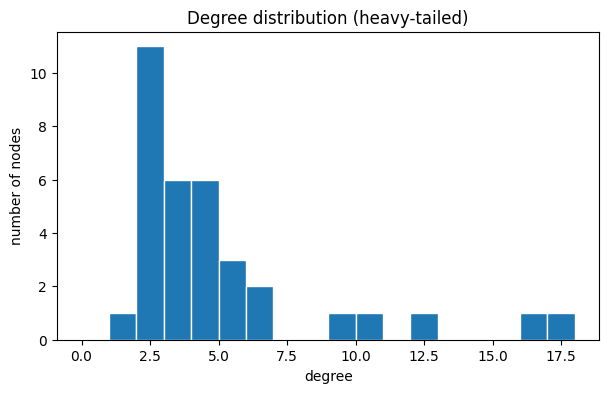

In [14]:
plt.figure(figsize=(7, 4))
plt.hist(list(dict(G.degree()).values()), bins=range(0, 19), edgecolor="white")
plt.title("Degree distribution (heavy-tailed)")
plt.xlabel("degree"); plt.ylabel("number of nodes")
plt.show()

**Try it (completion).** Read one node's degree two ways and confirm they agree.

In [15]:
# Completion: report node 2's degree from the Series and from the matrix row sum.
# The two must match. Uncomment and complete:
# print("from Series:", degree_series[2], "| from matrix:", int(A[2].sum()))

## Step 4 -- Centrality: who is important?

Degree is one notion of "important". **Betweenness** counts how often a node is on the shortest path
between others (a *bridge*); **closeness** measures how near a node is to everyone else. Let us compute
all three and compare their top five.

In [16]:
def top5(d):
    return sorted(d.items(), key=lambda kv: kv[1], reverse=True)[:5]

deg_c = nx.degree_centrality(G)
bet_c = nx.betweenness_centrality(G)
clo_c = nx.closeness_centrality(G)

print("Top 5 DEGREE     :", [(n, round(v, 3)) for n, v in top5(deg_c)])
print("Top 5 BETWEENNESS:", [(n, round(v, 3)) for n, v in top5(bet_c)])
print("Top 5 CLOSENESS  :", [(n, round(v, 3)) for n, v in top5(clo_c)])

Top 5 DEGREE     : [(33, 0.515), (0, 0.485), (32, 0.364), (2, 0.303), (1, 0.273)]
Top 5 BETWEENNESS: [(0, 0.438), (33, 0.304), (32, 0.145), (2, 0.144), (31, 0.138)]
Top 5 CLOSENESS  : [(0, 0.569), (2, 0.559), (33, 0.55), (31, 0.541), (8, 0.516)]


<details><summary>Expected Output</summary>

~~~text
Top 5 DEGREE     : [(33, 0.515), (0, 0.485), (32, 0.364), (2, 0.303), (1, 0.273)]
Top 5 BETWEENNESS: [(0, 0.438), (33, 0.304), (32, 0.145), (2, 0.144), (31, 0.138)]
Top 5 CLOSENESS  : [(0, 0.569), (2, 0.559), (33, 0.55), (31, 0.541), (8, 0.516)]
~~~
</details>

The measures **disagree**, and that is the lesson. The Officer (node 33) has the **most ties** (top
degree), but Mr. Hi (node 0) is the best **bridge** (top betweenness) and the most central by distance
(top closeness). Rank only by degree and you would miss that node 0 is the structural linchpin -- the
broker the whole network routes through. Let us colour the graph by betweenness to see the bridges.

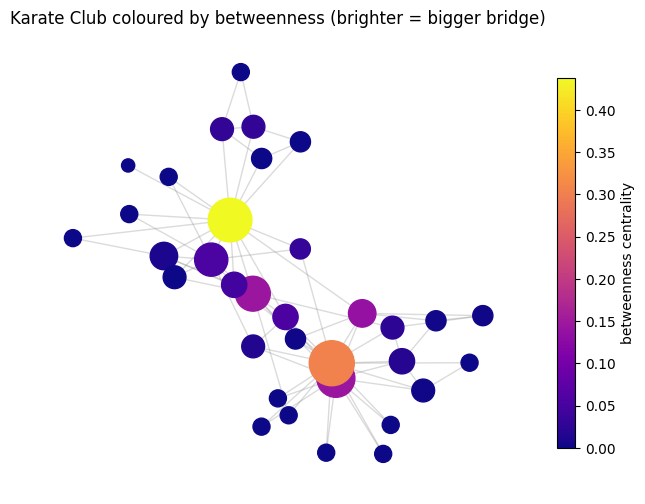

In [17]:
bet_vals = [bet_c[n] for n in G.nodes()]
plt.figure(figsize=(8, 6))
nx.draw_networkx_edges(G, pos, alpha=0.3, edge_color="#888888")
nodes = nx.draw_networkx_nodes(G, pos, node_color=bet_vals, cmap="plasma",
                               node_size=[30 + 60 * deg[n] for n in G.nodes()])
plt.colorbar(nodes, label="betweenness centrality", shrink=0.8)
plt.title("Karate Club coloured by betweenness (brighter = bigger bridge)")
plt.axis("off")
plt.show()

**Try it (completion).** Name the single top node by each measure.

In [18]:
# Completion: print the highest-ranked node of each centrality (first item of each
# top5 list). Which node leads degree? which leads betweenness? Complete:
# print("top degree:", top5(deg_c)[0], "| top betweenness:", top5(bet_c)[0])

## Step 5 -- Ego networks and local structure

Zoom into one node and its neighbourhood: its **ego network** is the node, its neighbours, and the edges
among them. We also read local structure -- how tight-knit the neighbourhood is (clustering), whether
the graph is one piece (components), and how far apart nodes are (distances).

In [19]:
ego0 = nx.ego_graph(G, 0, radius=1)
print("Mr. Hi's ego network (radius 1):",
      ego0.number_of_nodes(), "nodes,", ego0.number_of_edges(), "edges")
print("Clustering coefficient of node 0:", round(nx.clustering(G, 0), 3))
print("Average clustering (whole graph):", round(nx.average_clustering(G), 3))
print("Connected components:", nx.number_connected_components(G))
print("Shortest path 0 -> 33:", nx.shortest_path_length(G, 0, 33), "hops")
print("Diameter (longest shortest path):", nx.diameter(G))
print("Average shortest-path length:", round(nx.average_shortest_path_length(G), 3))

Mr. Hi's ego network (radius 1): 17 nodes, 34 edges
Clustering coefficient of node 0: 0.15
Average clustering (whole graph): 0.571
Connected components: 1
Shortest path 0 -> 33: 2 hops
Diameter (longest shortest path): 5
Average shortest-path length: 2.408


<details><summary>Expected Output</summary>

~~~text
Mr. Hi's ego network (radius 1): 17 nodes, 34 edges
Clustering coefficient of node 0: 0.15
Average clustering (whole graph): 0.571
Connected components: 1
Shortest path 0 -> 33: 2 hops
Diameter (longest shortest path): 5
Average shortest-path length: 2.408
~~~
</details>

The graph is **one connected piece**; any two members are at most **5** hops apart and **2.4** on
average -- a **small world**. Average clustering is high (0.571): your friends tend to be friends with
each other. Let us draw Mr. Hi's ego network on its own.

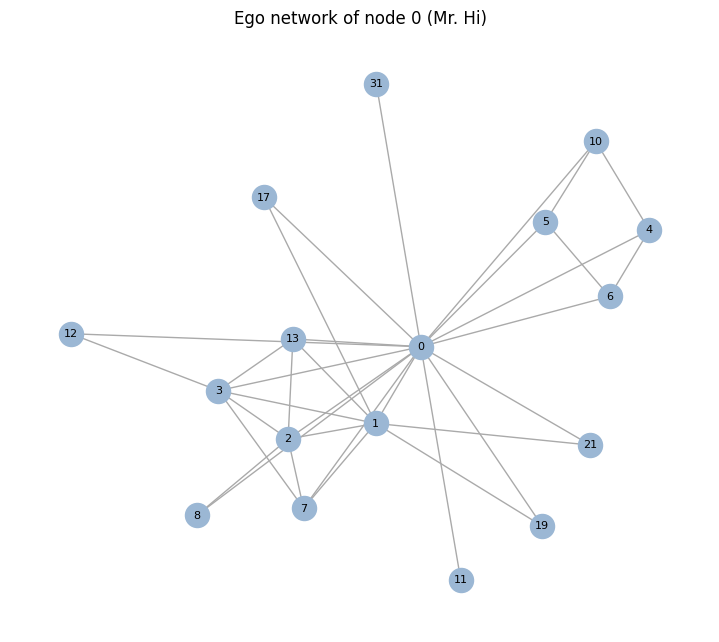

In [20]:
plt.figure(figsize=(7, 6))
pos_ego = nx.spring_layout(ego0, seed=42)
nx.draw(ego0, pos_ego, with_labels=True, node_size=300,
        node_color="#9bb7d4", edge_color="#aaaaaa", font_size=8)
plt.title("Ego network of node 0 (Mr. Hi)")
plt.show()

## Your Turn (Exercises)

### Exercise 1 -- Build a graph and read it

In [21]:
# TODO: build an undirected graph from this edge list, then print its number of
# nodes and edges and the degree of each node. Which node has the highest degree?
# edges = [(1, 2), (1, 3), (2, 3), (3, 4), (3, 5), (4, 5), (5, 6)]

### Exercise 2 -- Count shared friends with the matrix

In [22]:
# TODO: using A2 = A @ A, print how many friends nodes 0 and 2 share, then verify
# with list(nx.common_neighbors(G, 0, 2)). Do the two numbers match?

### Exercise 3 -- Written: spotting a broker
Node `31` ranks 5th in **betweenness** (0.138) yet has a degree of only **6** -- well below the leaders
(16 and 17) and even below nodes 2 and 32. In 2-3 sentences, explain what a node with high betweenness
*relative to its degree* represents in a social network, and why removing such a broker could fragment
the graph more than removing a higher-degree node.

## Summary

- A **graph** is nodes plus edges; choose **directed/undirected** and **weighted/unweighted** to match
  the relationship. NetworkX builds, inspects, measures, and draws it.
- A graph is also a **matrix**: the **adjacency matrix** `A`. The L18 operations now mean something --
  **row sum = degree** (`A @ ones`) and **`A @ A` = common-neighbour counts** (with degree on the
  diagonal).
- **Centrality** ranks importance, and the flavours **disagree**: degree (most ties), betweenness (the
  bridge), closeness (nearest to all). Report more than one.
- An **ego network** is one node's local world; **clustering**, **components**, and short **distances**
  describe local cohesion and the small-world structure.
- We measured *one graph's* local structure. **L26** asks the global question: do the nodes form
  **communities**, and can an algorithm recover the karate club's two real factions from structure alone?